Milestone 2 EDA: Understanding Donor Engagement for Nonprofit Organizations

For my project, I am interested in understanding donor behavior and identifying patterns that may help nonprofit organizations improve donor retention. I am focused on predicting donor churn, or identifying donors who may become inactive.

My hypothesis is that donor characteristics, engagement, and donation behavior may help predict whether someone becomes a monthly donor rather than a one-time donor. This EDA will explore these patterns and determine which variables may be useful for future predictive modeling.

Dataset used: Animal Charity: Wildlife Conservation Donations dataset from Kaggle. 

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
#load the dataset
df = pd.read_csv("animal_charity_donation_records.csv")

df.head()

,donor_id,age_group,gender,name,email,country,donation_type,donation_amount,donation_date,payment_method,newsletter_opt_in,referral_channel,sector,campaign
0,1a3d1fa7-bc89-40a9-a3b8-c1e9392456de,50-65,Female,Allison Hill,allison.hill40@yahoo.com,UK,Monthly,115.31,2024-10-24,Paypal,False,Website,Real Estate,Rescue Orphaned Gorillas
1,3b8faa18-37f8-488b-97fc-695a07a0ca6e,50-65,Female,Angie Henderson,angie.henderson758@gmail.com,USA,One-time,8.60,2024-06-21,Bank Transfer,False,Online advertising,Logistics,Rescue Orphaned Gorillas
2,72ff5d2a-386e-4be0-ab65-a6a48b8148f6,50-65,Female,Christina Santos,christina.santos275@gmail.com,USA,One-time,40.07,2024-08-21,Bank Transfer,False,Online advertising,Media & Communication,Marine Mammal Defense Mission
3,47229389-571a-4876-ac30-7511b2b9437a,18-29,Male,Aaron Shaffer,aaron.shaffer1@hotmail.com,USA,One-time,45.17,2023-10-09,Bank Transfer,False,Online advertising,Government,Wildlife Rescue Van Drive
4,580d7b71-d8f5-4413-9be6-128e18c26797,30-49,Female,Gabrielle Davis,gabrielle.davis890@yahoo.com,UK,One-time,85.84,2024-09-01,Bank Transfer,True,Newsletter,Science & Research,Habitat for Hope


In [3]:
#dataset overview
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of rows: 10000
Number of columns: 14

Column Names:
['donor_id', 'age_group', 'gender', 'name', 'email', 'country', 'donation_type', 'donation_amount', 'donation_date', 'payment_method', 'newsletter_opt_in', 'referral_channel', 'sector', 'campaign']


My Initial Data Review: The dataset contains 10,000 donation records and 14 variables. The variables include donor information, donation behavior, engagement information, and campaign information. The dataset is small enough to work with efficiently while still providing enough observations to explore patterns in donor behavior. One important observation is that each "donor_id" is unique. Because there are no repeated donor IDs, I cannot directly track an individual donor's giving behavior over time. This is why I will use "donation_type" as the target and examine differences between monthly and one-time donors.

In [8]:
#review variable types and dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   donor_id            10000 non-null  object        
 1   age_group           10000 non-null  object        
 2   gender              10000 non-null  object        
 3   name                10000 non-null  object        
 4   email               10000 non-null  object        
 5   country             10000 non-null  object        
 6   donation_type       10000 non-null  object        
 7   donation_amount     10000 non-null  float64       
 8   donation_date       10000 non-null  datetime64[ns]
 9   payment_method      10000 non-null  object        
 10  newsletter_opt_in   10000 non-null  bool          
 11  referral_channel    10000 non-null  object        
 12  sector              10000 non-null  object        
 13  campaign            10000 non-null  object     

In [9]:
#separate numerical and categorical variables
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(
    include=["object", "bool"]
).columns

print("Numerical Variables:")
print(numeric_columns.tolist())

print("\nCategorical Variables:")
print(categorical_columns.tolist())

Numerical Variables:
['donation_amount', 'donation_year', 'donation_month']

Categorical Variables:
['donor_id', 'age_group', 'gender', 'name', 'email', 'country', 'donation_type', 'payment_method', 'newsletter_opt_in', 'referral_channel', 'sector', 'campaign', 'donation_dayofweek']


Most of the variables in this dataset are categorical. Examples include age group, gender, country, donation type, payment method, referral channel, sector, and campaign. The "newsletter_opt_in" is a Boolean variable whether that donor opted in to receive newsletters. The "donation_amount" is the main numerical variable. The donation date is currently stored as text, so I will convert it to a date format before continuing the analysis. The "donor_id", name, and email columns identify individual donors not individual giving so it's not relevant here.

In [10]:
#convert donation_date
df["donation_date"] = pd.to_datetime(df["donation_date"])

df["donation_date"].dtype

dtype('<M8[ns]')

In [11]:
#create date features for EDA
df["donation_year"] = df["donation_date"].dt.year
df["donation_month"] = df["donation_date"].dt.month
df["donation_dayofweek"] = df["donation_date"].dt.day_name()

The "donation_date" variable was originally stored as text, so I converted it to a datetime format. I also created year, month, and day-of-week variables. These features make it easier to explore whether donation behavior changes over time.

In [12]:
#descriptive statistics for donation amount
df["donation_amount"].describe()

count    10000.000000
mean        51.696998
std         56.745420
min          0.550000
25%         12.070000
50%         28.110000
75%         71.592500
max        702.930000
Name: donation_amount, dtype: float64

Descriptive Statistics:
The average donation is approximately 51.70. The median donation donation amount is 28.11. The fact that the mean is obviously higher than the median suggests that donation amounts may be right-skewed, with some larger donations increasing the average. Donation amounts range from 0.55 to 702.93. The large difference between the typical donation and the maximum donation also suggests that there may be some high-value donations that appear as potential outliers.

In [13]:
#check for missing values
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percent Missing": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Values,Percent Missing
donor_id,0,0.0
age_group,0,0.0
gender,0,0.0
name,0,0.0
email,0,0.0
country,0,0.0
donation_type,0,0.0
donation_amount,0,0.0
donation_date,0,0.0
payment_method,0,0.0


There are no missing values in the dataset.

In [14]:
#check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Check whether donor IDs are repeated
print("Unique donor IDs:", df["donor_id"].nunique())

Number of duplicate rows: 0
Unique donor IDs: 10000


There are no duplicate rows in the dataset, and all 10,000 donor IDs are unique. This means each row represents a different donor.
This means that the "donor_id", "name", and "email" variables are going to be useful for identifying individual records, but they are not particularly useful predictive features for this project. Including these variables could add unnecessary information without describing meaningful donor behavior, so I would exclude them from future predictive modeling.

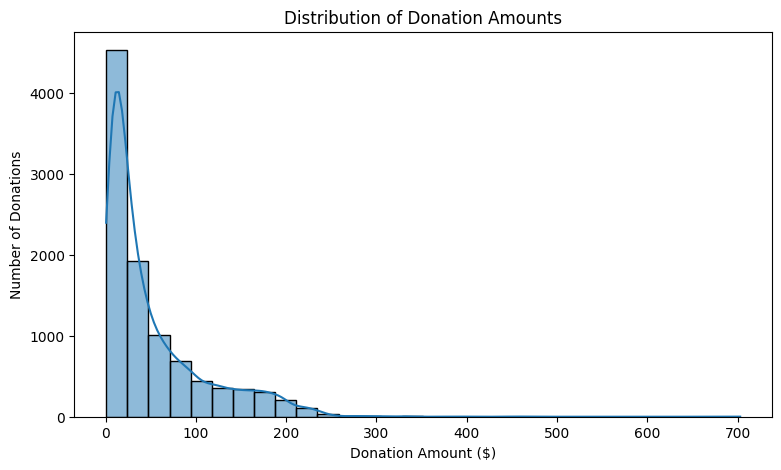

In [17]:
#number of donations by amount of donation given
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="donation_amount",
    bins=30,
    kde=True
)

plt.title("Distribution of Donation Amounts")
plt.xlabel("Donation Amount ($)")
plt.ylabel("Number of Donations")
plt.show()

The donation amount distribution is right-skewed. Most donations are toward the lower end of the range (under 100.00), while a smaller number of donors gave much larger amounts. This explains why the average donation is higher than the median. This pattern makes sense for charitable giving because many donors may donate smaller amounts while a smaller group gives a larger donation.

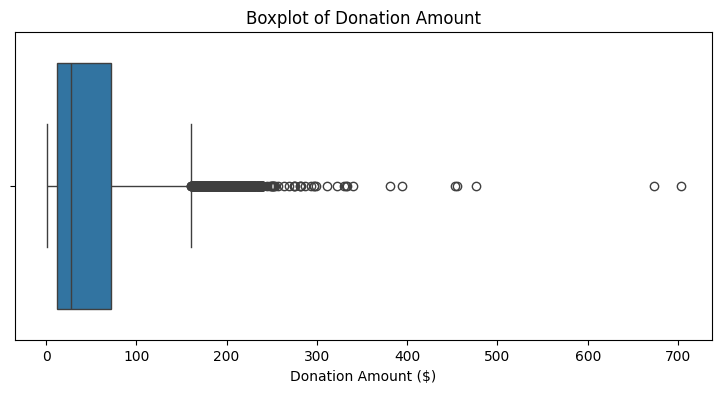

In [18]:
#look for outliers via boxplot
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df,
    x="donation_amount"
)

plt.title("Boxplot of Donation Amount")
plt.xlabel("Donation Amount ($)")
plt.show()

The boxplot shows several high donation amounts that may be considered statistical outliers. However, I wouldn't automatically remove these outliers. Large donations are realistic in fundraising data and could represent high-value donors rather than data-entry errors. Before modeling, I may consider whether transforming the donation amount or using a model that is less sensitive to extreme values would be more appropriate than deleting these records altogether.

In [19]:
#examine the target variable
df["donation_type"].value_counts()

donation_type
One-time    7085
Monthly     2915
Name: count, dtype: int64

In [20]:
#percentages
df["donation_type"].value_counts(normalize=True).mul(100).round(2)

donation_type
One-time    70.85
Monthly     29.15
Name: proportion, dtype: float64

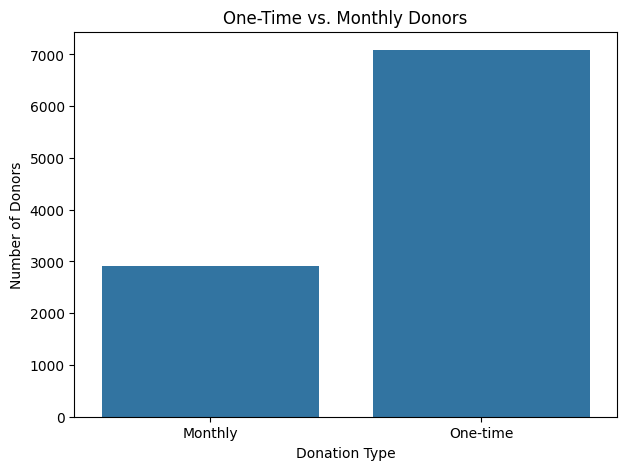

In [21]:
#graph the target variable information
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="donation_type"
)

plt.title("One-Time vs. Monthly Donors")
plt.xlabel("Donation Type")
plt.ylabel("Number of Donors")
plt.show()

The target variable is the "donation_type". About 70.85% of the records are one-time donations, while 29.15% are monthly donations. This essentially shows that one-time donors are much more common in the dataset. The target is somewhat imbalanced, which will be important to consider when building a predictive model. Accuracy alone may not be enough to evaluate the model because a model could favor the larger one-time donor group.

In [23]:
#distribution by category
categorical_features = [
    "age_group",
    "gender",
    "country",
    "payment_method",
    "newsletter_opt_in",
    "referral_channel",
    "campaign"
]

for column in categorical_features:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- age_group ---
age_group
30-49    4011
50-65    3401
18-29    1432
66-80    1156
Name: count, dtype: int64

--- gender ---
gender
Male      4908
Female    4697
Other      395
Name: count, dtype: int64

--- country ---
country
USA             2146
UK              1380
France          1103
Germany          998
Canada           844
Australia        650
South Africa     523
New Zealand      508
India            504
Brazil           490
Netherlands      476
Finland          378
Name: count, dtype: int64

--- payment_method ---
payment_method
Paypal           2576
Bank Transfer    2494
Credit Card      2477
Cheque           2453
Name: count, dtype: int64

--- newsletter_opt_in ---
newsletter_opt_in
False    5008
True     4992
Name: count, dtype: int64

--- referral_channel ---
referral_channel
Word of mouth         1788
Newsletter            1659
Website               1654
Local event           1653
Online advertising    1639
Social Media          1607
Name: count, dtype: int64

--- camp

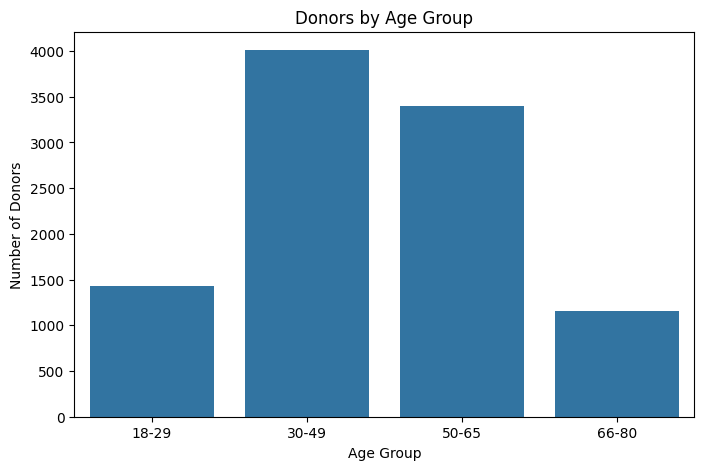

In [24]:
#age distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age_group",
    order=["18-29", "30-49", "50-65", "66-80"]
)

plt.title("Donors by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Donors")
plt.show()

The largest donor age group is 30-49, followed by donors between 50-65. The 18-29 and 66-80 groups appear less frequently in the dataset.
This shows that the donor population is not evenly distributed across age groups. Age group may be worth comparing with donation type to see whether monthly giving is more common among certain age groups.

In [25]:
#bivariate EDA: age vs target variable
age_donation = pd.crosstab(
    df["age_group"],
    df["donation_type"],
    normalize="index"
) * 100

age_donation.round(2)

donation_type,Monthly,One-time
age_group,,
18-29,28.56,71.44
30-49,28.95,71.05
50-65,29.46,70.54
66-80,29.67,70.33


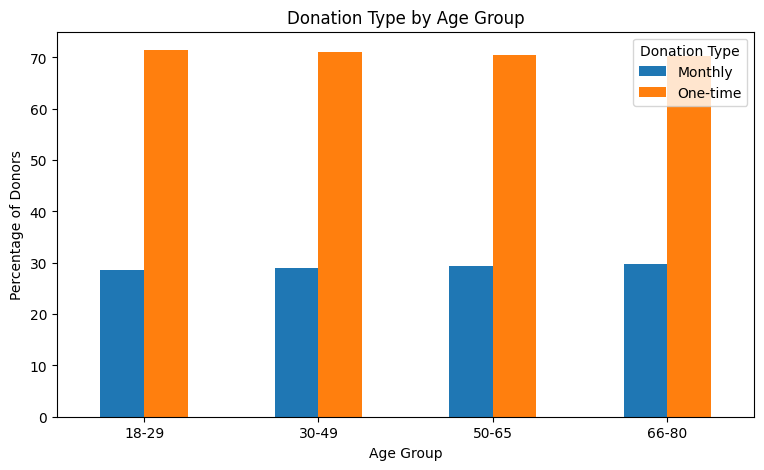

In [28]:
#graph of comparison
age_donation.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Donation Type by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Donors")
plt.xticks(rotation=0)
plt.legend(title="Donation Type")
plt.show()

Again, the age distribution shows that most donors are between the ages of 30-49, followed by the 50-65 age group. The 18-29 and 66-80 groups contain fewer donors. This means the dataset is not evenly distributed across age groups. Because the middle-aged groups contain more donors, I want to be careful not to assume that age automatically leads to monthly giving. I will compare age with donation type and donation amount to see whether there are meaningful differences.

In [43]:
#compare newsletter vs. target variable 
newsletter_donation = pd.crosstab(
    df["newsletter_opt_in"],
    df["donation_type"],
    normalize="index"
) * 100

newsletter_donation.round(2)

donation_type,Monthly,One-time
newsletter_opt_in,,
False,28.65,71.35
True,29.65,70.35


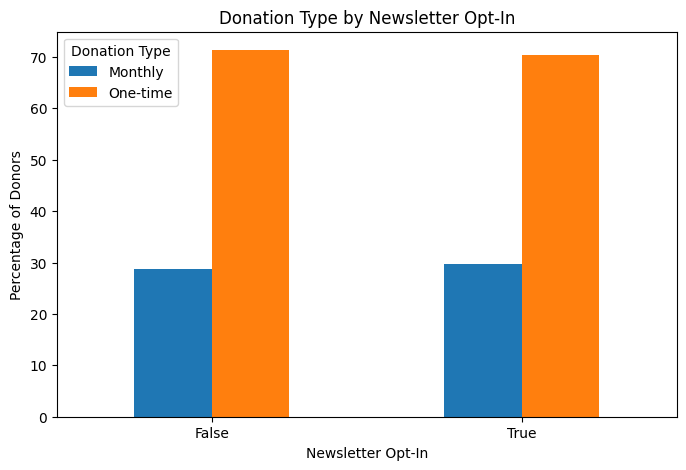

In [44]:
newsletter_donation.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Donation Type by Newsletter Opt-In")
plt.xlabel("Newsletter Opt-In")
plt.ylabel("Percentage of Donors")
plt.xticks(rotation=0)
plt.legend(title="Donation Type")
plt.show()

Newsletter participation does not appear to have a strong relationship with donation type. Donors who opted into the newsletter and those who did not have very similar percentages of monthly and one-time donations so it appears to be insignificant. In both groups, around 70% of donors are one-time donors and around 30% are monthly donors. This suggests that newsletter participation by itself may not be a strong predictor of whether someone becomes a monthly donor.

In [45]:
#compare donation amount given vs target variable
df.groupby("donation_type")["donation_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
donation_type,,,,,,,,
Monthly,2915.0,100.013822,61.901497,2.55,47.205,91.87,150.885,239.87
One-time,7085.0,31.817881,40.162005,0.55,9.430,18.89,38.410,702.93


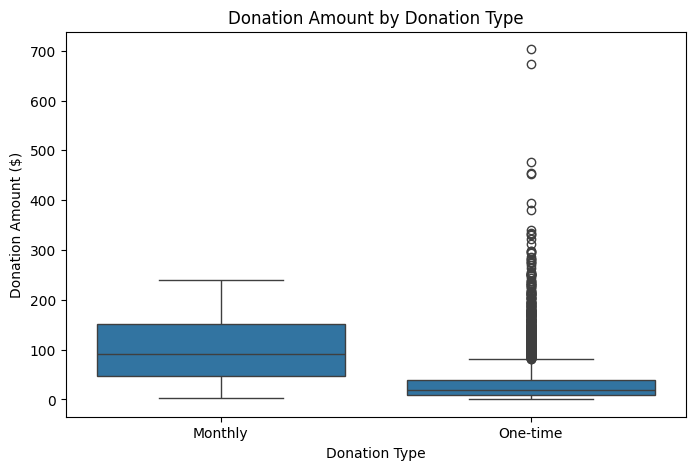

In [46]:
#plot the comparison
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="donation_type",
    y="donation_amount"
)

plt.title("Donation Amount by Donation Type")
plt.xlabel("Donation Type")
plt.ylabel("Donation Amount ($)")
plt.show()

The boxplot shows a difference in donation amounts between monthly and one-time donors. Monthly donors generally have higher donation amounts, with a much higher median than one-time donors. One-time donations are usually smaller, but this group also contains many high-value outliers, including a few donations above 400 dollars and even 700 dollars. This suggests that a donor can still make a very large donation without becoming a monthly donor. Overall, donation amount appears to have a stronger relationship with donation type than many of the other features I've looked at so far.

In [34]:
#compare referral vs target variable
referral_donation = pd.crosstab(
    df["referral_channel"],
    df["donation_type"],
    normalize="index"
) * 100

referral_donation.round(2)

donation_type,Monthly,One-time
referral_channel,,
Local event,29.70,70.30
Newsletter,27.91,72.09
Online advertising,29.59,70.41
Social Media,30.12,69.88
Website,26.72,73.28
Word of mouth,30.76,69.24


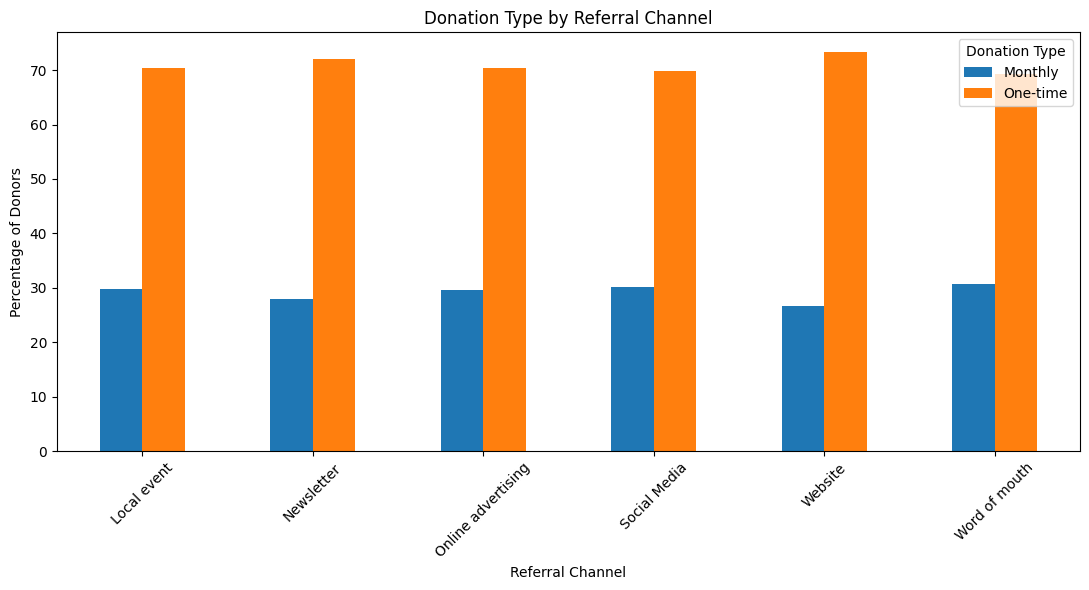

In [35]:
#graph to show how many donors are coming from referrals
referral_donation.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Donation Type by Referral Channel")
plt.xlabel("Referral Channel")
plt.ylabel("Percentage of Donors")
plt.xticks(rotation=45)
plt.legend(title="Donation Type")
plt.tight_layout()
plt.show()

Donation patterns are fairly similar across the different referral channels. One-time donations make up around 70% or more of the donations for each channel, while monthly donations generally remain around 30%. Word of mouth and social media appear to have slightly higher percentages of monthly donors, while the website appears slightly lower. However, these differences are small. Based on this graph alone, referral channel does not appear to have a major relationship with whether someone becomes a monthly donor.

In [47]:
#compare campaign vs target variable
campaign_donation = pd.crosstab(
    df["campaign"],
    df["donation_type"],
    normalize="index"
) * 100

campaign_donation.round(2)

donation_type,Monthly,One-time
campaign,,
Defend the Great Apes,30.57,69.43
Habitat for Hope,28.25,71.75
Jungle Education Project,29.39,70.61
Marine Mammal Defense Mission,28.06,71.94
Reforest the Sanctuary,30.09,69.91
Rescue Orphaned Gorillas,28.20,71.80
Wildlife Rescue Van Drive,29.54,70.46


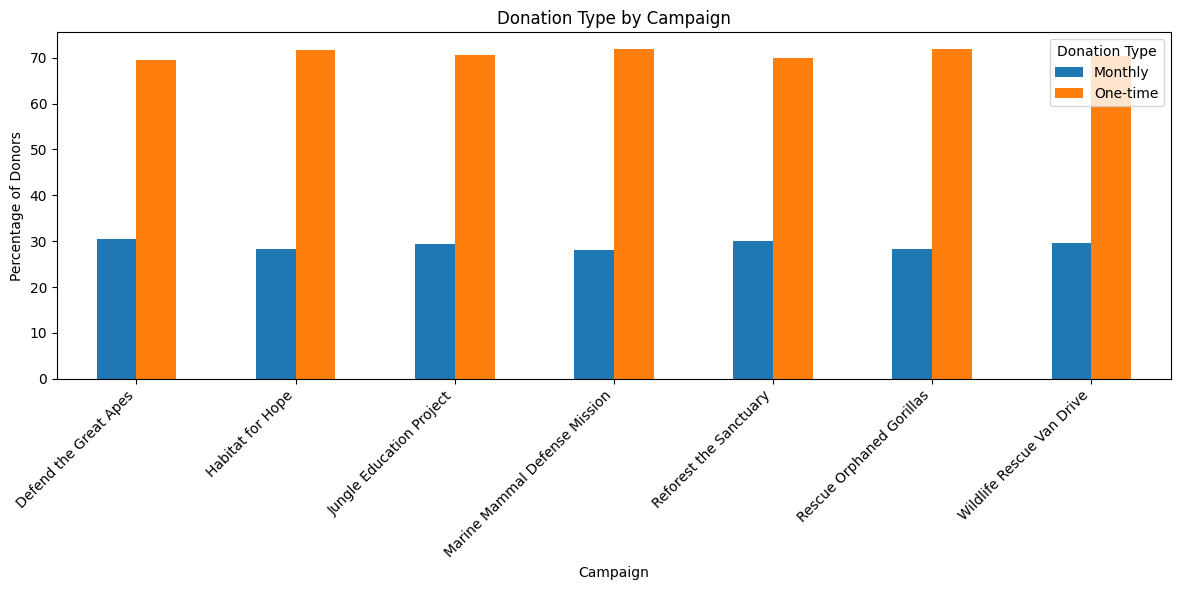

In [37]:
#graph to show the comparison
campaign_donation.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Donation Type by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Percentage of Donors")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Donation Type")
plt.tight_layout()
plt.show()

The percentage of monthly and one-time donors is also similar across the different campaigns. Each campaign has approximately 28-30% monthly donors and around 70-72% one-time donors. There are small differences between campaigns, but none of them appear large enough to show a clear relationship with monthly giving. This suggests that campaign choice may provide less predictive information than a feature such as donation amount and its probably insignificant for review.

In [38]:
#create numerical versions of certain variables
df["monthly_donor"] = df["donation_type"].map({
    "One-time": 0,
    "Monthly": 1
})

df["newsletter_numeric"] = df["newsletter_opt_in"].astype(int)

df["age_group_numeric"] = df["age_group"].map({
    "18-29": 1,
    "30-49": 2,
    "50-65": 3,
    "66-80": 4
})

Prep Variables for Correlation Analysis: Most variables in this dataset are categorical, so a standard correlation matrix cannot be used directly to all of them. To make a basic correlation comparison possible, I created numerical versions of donation type, newsletter participation, and age group. For "monthly_donor", one-time donations are represented by 0 and monthly donations by 1. Newsletter participation is also represented by 0 and 1. Age groups are ordered from the youngest to oldest. These variables will allow me to explore whether there are noticeable linear relationships with donation amount and monthly giving.

In [39]:
#Correlation Matrix
correlation_features = [
    "donation_amount",
    "monthly_donor",
    "newsletter_numeric",
    "age_group_numeric"
]

correlation_matrix = df[correlation_features].corr()

correlation_matrix.round(3)

,donation_amount,monthly_donor,newsletter_numeric,age_group_numeric
donation_amount,1.000,0.546,0.007,0.140
monthly_donor,0.546,1.000,0.011,0.008
newsletter_numeric,0.007,0.011,1.000,-0.008
age_group_numeric,0.140,0.008,-0.008,1.000


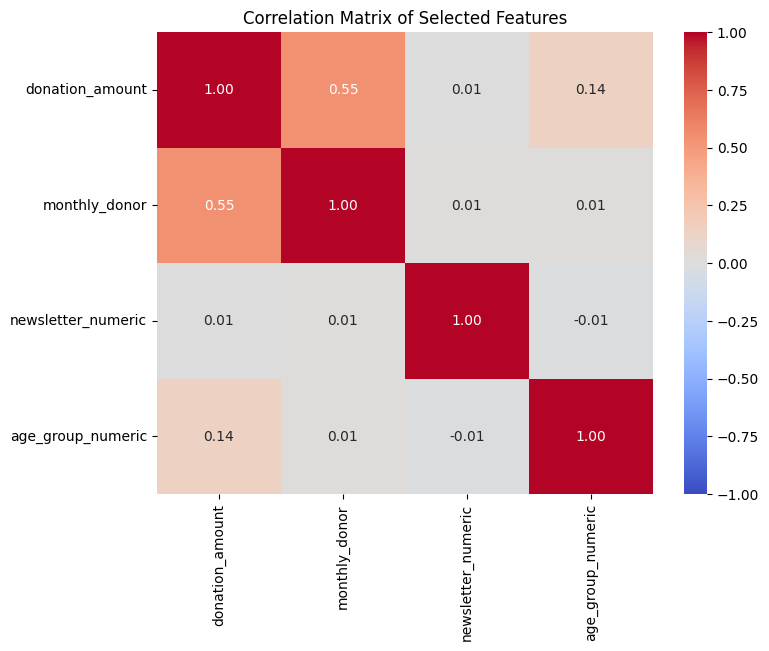

In [40]:
#graph matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Selected Features")
plt.show()

The correlation matrix shows that donation amount has the strongest relationship with monthly donor status, with a positive correlation of 0.55. This supports what I observed in the boxplots, where monthly donors generally gave higher amounts than one-time donors. Age group has a weak positive correlation of 0.14 with donation amount, meaning donation amounts may increase slightly across the older age groups. However, age group has only a 0.01 correlation with monthly donor status. Newsletter participation also has only a 0.01 correlation with monthly donor status and donation amount. Overall, most of the selected variables have very weak relationships with one another. Donation amount stands out as the feature with the clearest relationship to the target variable.

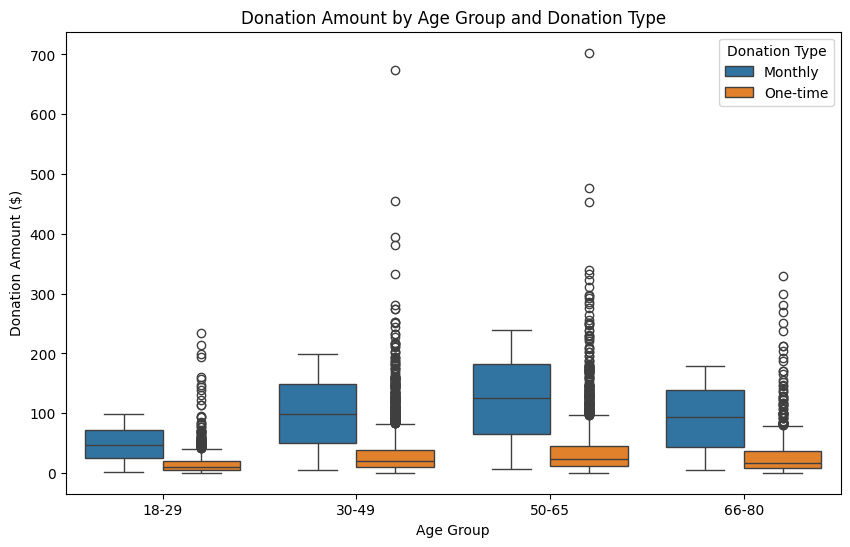

In [48]:
#multivariate EDA
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="age_group",
    y="donation_amount",
    hue="donation_type",
    order=["18-29", "30-49", "50-65", "66-80"]
)

plt.title("Donation Amount by Age Group and Donation Type")
plt.xlabel("Age Group")
plt.ylabel("Donation Amount ($)")
plt.legend(title="Donation Type")
plt.show()

Looking at age group, donation amount, and donation type together provides a clearer picture of donor behavior. Across all age groups, monthly donors generally have higher donation amounts than one-time donors. Donation amounts also appear to increase from the 18-29 group into the middle and older age groups, especially for monthly donors. The 50-65 group appears to have the highest typical monthly donation amounts. However, one-time donors in every age group also contain several high-value outliers. This supports the correlation results. Age has only a weak relationship with donation amount and almost no relationship with monthly donor status, while donation amount has a much stronger relationship with monthly giving.

Hypothesis Review: 
My hypothesis was that donor characteristics, engagement, and donation behavior may help predict whether someone is a monthly donor rather than a one-time donor. Based on the EDA, this hypothesis is partially supported. The strongest evidence comes from donation amount. Monthly donors generally have higher donation amounts than one-time donors, and donation amount has a correlation of 0.55 with monthly donor status. This suggests that donation amount may be useful for predicting the target. However, several other variables showed much weaker relationships. Newsletter participation and age group both had correlations of approximately 0.01 with monthly donor status. Referral channels and campaigns also showed similar monthly-donor percentages across their categories. Therefore, the EDA suggests that some donor behaviors may be useful for predicting monthly giving, but not every donor characteristic appears equally useful.

My Model Strategy based off this EDA: The EDA gives me a better idea of how I should approach the predictive modeling stage. Donation amount appears to be one of the most useful features because it has the strongest relationship with monthly donor status. Other categorical variables, such as age group, referral channel, campaign, payment method, and newsletter participation, can still be tested to determine whether they provide additional predictive value when combined. The target variable is somewhat imbalanced because about 71% of the records are one-time donations and 29% are monthly donations. Because of this, I don't think I should rely only on accuracy when evaluating future models. Metrics such as precision, recall, F1-score, and a confusion matrix will provide a better understanding of model performance. I will also exclude identifying variables such as donor ID, name, and email because they describe individual donors rather than meaningful donor behavior- and that's not necessarily needed right now (I'm looking at characteristics for donor churn not reaching out to donors right now). Finally, the large outliers in donation amount should be considered during modeling rather than automatically removed because they may represent legitimate high-value donors.

Conclusion: This EDA helped me better understand the donor dataset and determine which features may be useful for predicting monthly donor behavior. One of the clearest findings was the relationship between donation amount and donation type. Monthly donors generally gave higher amounts, and donation amount had a correlation of 0.55 with monthly donor status. In comparison, age group and newsletter participation had very weak relationships with the target. Referral channel and campaign also showed only small differences in the percentage of monthly donors. The EDA also identified several large donation outliers, especially among one-time donors. I chose not to remove these values because they may represent legitimate large donations. Overall, my hypothesis was partially supported. Some donor behavior, particularly donation amount, appears related to monthly giving, while several other donor characteristics show weaker relationships. These findings will help guide feature selection and model evaluation during the next stage of the project.

Reference: Zhu, W. (2025, June 18). Animal Charity: Wildlife Conservation Donations. Kaggledatasets. https://www.kaggle.com/datasets/jaderz/synthetic-animal-charity-donations